# Temperature Data Analysis: 7 US Cities

## Collect & Clean Data

In [1]:
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import CITIES_RAW_DIR, BASE_TEMP, WINTER_MONTHS, SUMMER_MONTHS

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})
CITY_COLORS = {
    "Chicago": "#1f4e79", "New_York": "#c0392b", "Boston": "#2ca02c",
    "Minneapolis": "#9467bd", "Dallas": "#d4882b", "Los_Angeles": "#7f7f7f",
    "Seattle": "#17becf",
}

# Load the 7 cities (files produced by 1_data_splitting_update)
df_cities = {}
for f in sorted(CITIES_RAW_DIR.glob("*.csv")):
    d = pd.read_csv(f, parse_dates=["DATE"]).set_index("DATE")
    # NOAA raw archive is in °F, convert to °C (project convention, DD base 18°C)
    # the >60 guard makes it idempotent (a °C file, max ~40, is left untouched).
    for _c in ("TAVG", "TMIN", "TMAX"):
        if _c in d and d[_c].max(skipna=True) > 60:
            d[_c] = (d[_c] - 32) * 5.0 / 9.0
    # frozen project convention: T = (TMIN+TMAX)/2, TAVG as fallback
    both = d["TMIN"].notna() & d["TMAX"].notna()
    d["T"] = np.where(both, (d["TMIN"] + d["TMAX"]) / 2, d["TAVG"])
    d["month"]  = d.index.month
    d["winter"] = d["month"].isin(WINTER_MONTHS).astype(int)
    d["summer"] = d["month"].isin(SUMMER_MONTHS).astype(int)
    d["HDD"] = np.maximum(BASE_TEMP - d["T"], 0)
    d["CDD"] = np.maximum(d["T"] - BASE_TEMP, 0)
    df_cities[f.stem] = d

print(", ".join(df_cities), f"| {len(next(iter(df_cities.values()))):,} days/city")

Boston, Chicago, Dallas, Los_Angeles, Minneapolis, New_York, Seattle | 27,760 days/city


In [2]:
df_cities["Chicago"].head(3)

,TAVG,TMIN,TMAX,T,month,winter,summer,HDD,CDD
DATE,,,,,,,,,
1950-01-01,6.666667,5.555556,8.888889,7.222222,1,1,0,10.777778,0.0
1950-01-02,8.333333,7.222222,11.111111,9.166667,1,1,0,8.833333,0.0
1950-01-03,11.111111,-5.000000,15.000000,5.000000,1,1,0,13.000000,0.0


The data comes from the [National Oceanic and Atmospheric Administration](https://www.noaa.gov/).

It gives direct access to the daily maximum and minimum temperature of the cities under
study, as well as the daily average temperature:
$T = \frac{T_{max}+T_{min}}{2}$

### Choice of reference cities

The four core stations (**Chicago O'Hare, New York JFK, Boston Logan and Minneapolis-St Paul**) meet three complementary criteria.

1. HDD / natural-gas demand correlation

These cities sit in the **Midwest and the Northeast**, the two largest winter
natural-gas consumption areas in the United States. Population density is high, residential
heating relies heavily on gas, and the relationship between cumulative HDD and gas demand is
nearly linear, which makes the temperature/gas-price coupling particularly legible and
tractable to model.

Source: [EIA, Natural Gas Consumption by State: Residential Sector](https://www.eia.gov/dnav/ng/NG_SUM_LSUM_A_EPG0_VRS_MMCF_M.htm)

2. Standardized contracts listed on the CME

The Chicago Mercantile Exchange (CME, one of the largest derivatives exchanges in the world)
has listed standardized HDD contracts on these cities since 1999. This market framework is an
important practical condition: it guarantees structured, comparable reference data for these
cities, which eases the later stages of the project.

3. Coherent geographic coverage

The four cities cover the two dominant consumption corridors:

<div align="center">

| City | Area |
|---|---|
| Chicago O'Hare | Midwest |
| Minneapolis-St Paul | Midwest |
| New York JFK | Northeast |
| Boston Logan | Northeast |

</div>

Three additional cities (**Dallas, Los Angeles, Seattle**) were added to test the
**generalisability** of the models outside the gas corridors (southern continental,
Mediterranean and oceanic climates respectively).

In [ ]:
stats = pd.DataFrame({
    city: {
        "mean": d["T"].mean(), "std": d["T"].std(),
        "min": d["T"].min(), "max": d["T"].max(),
        "skew": d["T"].skew(), "kurtosis": d["T"].kurtosis(),
        "%NaN": d["T"].isna().mean() * 100,
    } for city, d in df_cities.items()
}).T.round(3)
stats

,mean,std,min,max,skew,kurtosis,%NaN
Boston,11.042,9.574,-19.167,33.611,-0.149,-0.859,0.000
Chicago,9.930,11.132,-27.778,33.611,-0.309,-0.745,0.000
Dallas,19.136,9.082,-13.333,36.389,-0.402,-0.732,4.356
Los_Angeles,17.325,3.596,5.833,34.444,0.093,-0.161,0.000
Minneapolis,7.755,12.776,-31.389,32.778,-0.357,-0.804,0.000
New_York,12.945,9.592,-15.833,34.444,-0.209,-0.916,0.000
Seattle,11.266,5.843,-12.222,31.389,0.021,-0.422,0.004


We notice that the `TAVG` variable has several missing values. It is rebuilt from
`TMAX` and `TMIN` as: $T = \frac{T_{max}+T_{min}}{2}$

In [4]:
# Missing values per variable and per city (before pipeline imputation)
pd.DataFrame({c: d[["TAVG", "TMIN", "TMAX", "T"]].isna().sum()
              for c, d in df_cities.items()}).T

,TAVG,TMIN,TMAX,T
Boston,0,0,0,0
Chicago,0,0,0,0
Dallas,1209,1209,1209,1209
Los_Angeles,0,0,0,0
Minneapolis,0,0,0,0
New_York,0,0,0,0
Seattle,1,1,0,1


## Data Visualisation

Winter and summer periods for CME contracts in these regions:
- Summer: April to September
- Winter: October to March

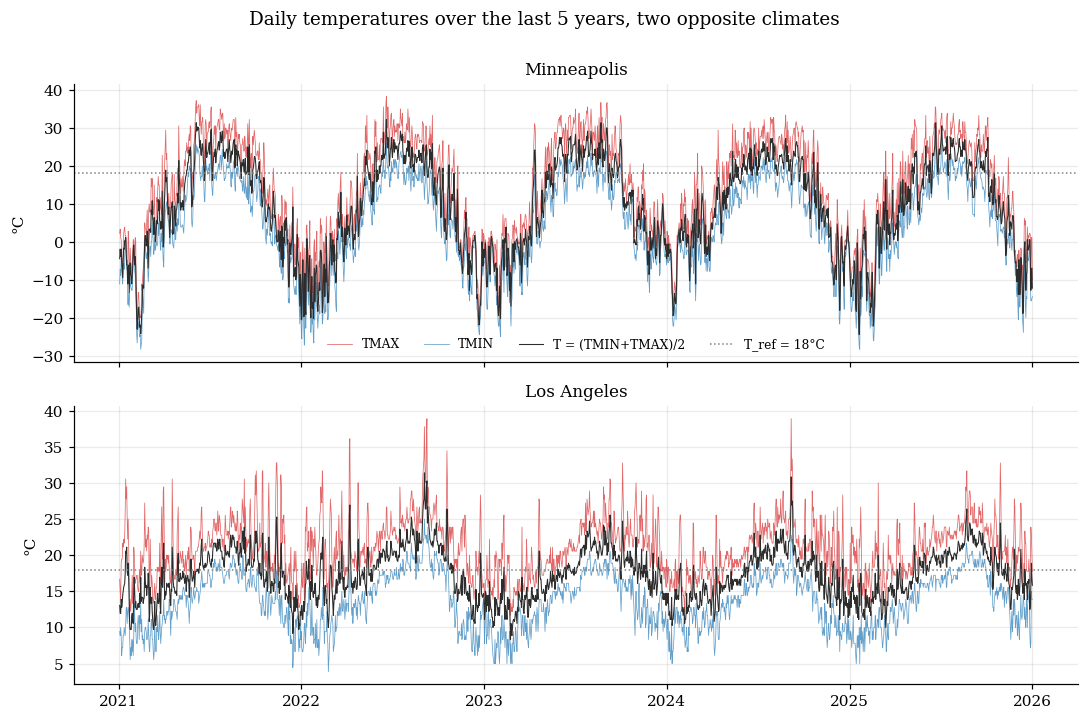

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for ax, city in zip(axes, ["Minneapolis", "Los_Angeles"]):
    d = df_cities[city].iloc[-365 * 5:]
    ax.plot(d.index, d["TMAX"], color="#d62728", lw=0.5, alpha=0.7, label="TMAX")
    ax.plot(d.index, d["TMIN"], color="#1f77b4", lw=0.5, alpha=0.7, label="TMIN")
    ax.plot(d.index, d["T"],    color="#2c2c2c", lw=0.7, label="T = (TMIN+TMAX)/2")
    ax.axhline(BASE_TEMP, color="grey", ls=":", lw=1, label=f"T_ref = {BASE_TEMP:.0f}°C")
    ax.set_title(city.replace("_", " ")); ax.set_ylabel("°C")
axes[0].legend(frameon=False, ncols=4, fontsize=8)
fig.suptitle("Daily temperatures over the last 5 years, two opposite climates", y=1.0)
fig.tight_layout()

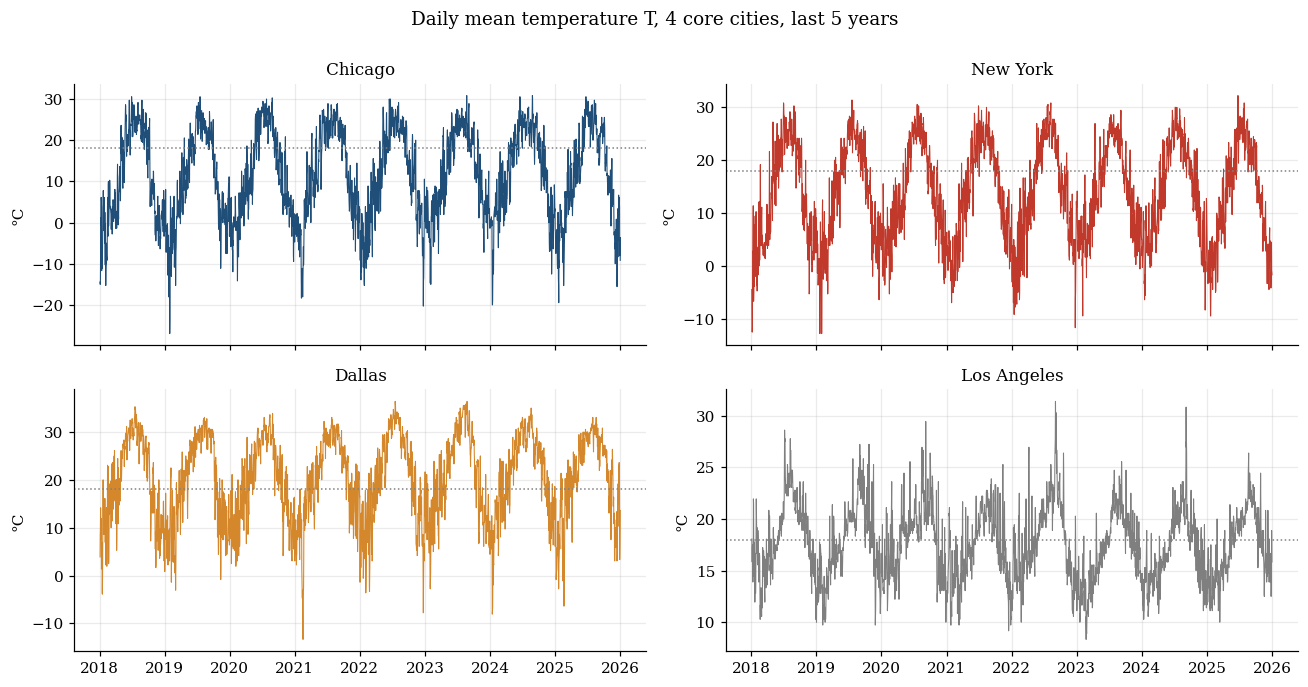

In [6]:
# Daily mean temperature T for the 4 core cities, last 5 years
fig, axes = plt.subplots(2, 2, figsize=(12, 6.2), sharex=True)
for ax, city in zip(axes.flat, ["Chicago", "New_York", "Dallas", "Los_Angeles"]):
    s = df_cities[city].iloc[-365 * 8:]
    ax.plot(s.index, s["T"], lw=0.7, color=CITY_COLORS[city])
    ax.axhline(BASE_TEMP, color="grey", ls=":", lw=1)
    ax.set_title(city.replace("_", " ")); ax.set_ylabel("°C")
fig.suptitle("Daily mean temperature T, 4 core cities, last 5 years", y=1.0)
fig.tight_layout()

The temperature series exhibit two distinct components:

- **A deterministic seasonal trend**: temperature oscillates around an annual mean with warm
  (summer) and cold (winter) phases, following an approximately sinusoidal dynamic of period
  **1 year ≈ 365.25 days**.

- **A stochastic component**: around this trend we observe random irregularities such as
  unusual cold or heat spikes and short trend breaks, reflecting the unpredictable nature of
  weather over horizons of a few days to a few weeks.

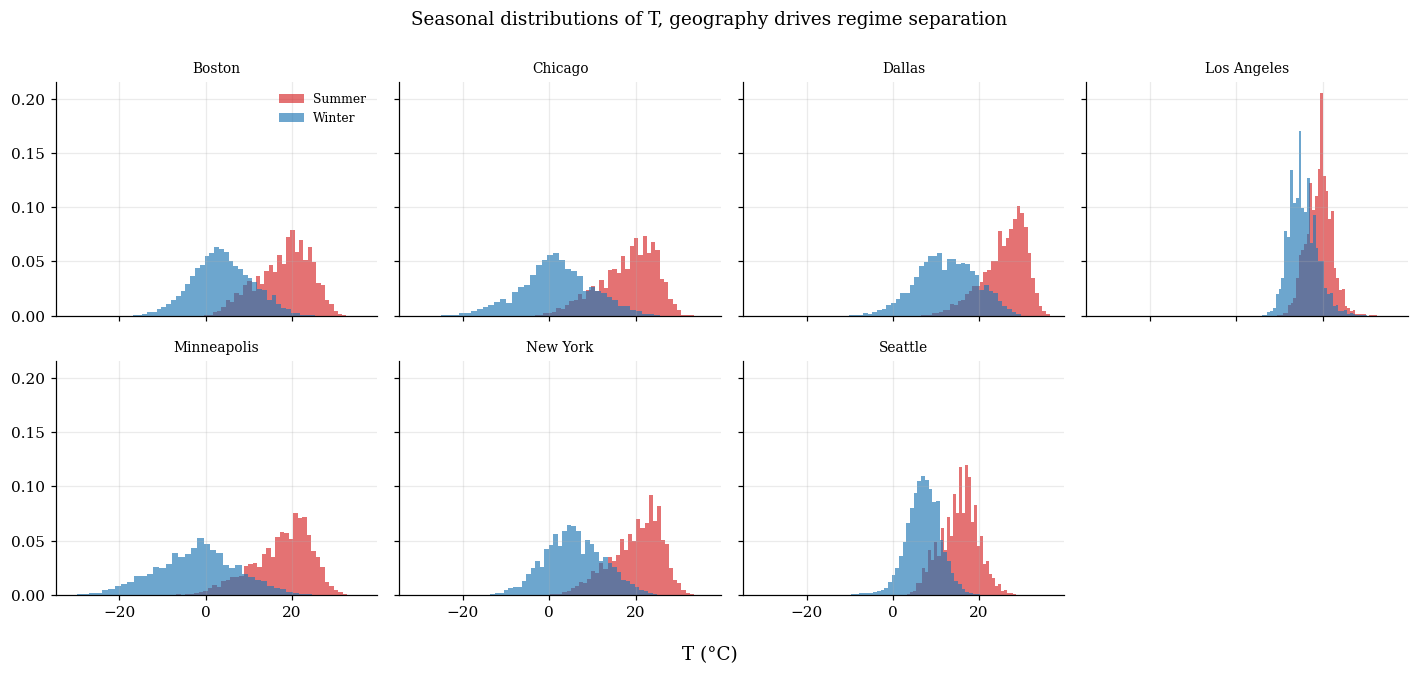

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharex=True, sharey=True)
for ax, (city, d) in zip(axes.flat, df_cities.items()):
    ax.hist(d.loc[d.summer == 1, "T"], bins=40, density=True, alpha=0.65,
            color="#d62728", label="Summer")
    ax.hist(d.loc[d.winter == 1, "T"], bins=40, density=True, alpha=0.65,
            color="#1f77b4", label="Winter")
    ax.set_title(city.replace("_", " "), fontsize=9)
axes.flat[-1].axis("off")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Seasonal distributions of T, geography drives regime separation", y=1.0)
fig.supxlabel("T (°C)"); fig.tight_layout()

In [8]:
# 3rd and 4th moments by season, quantifies what the histograms show
pd.DataFrame([{
    "City": c,
    "Skew winter": d.loc[d.winter == 1, "T"].skew(),
    "Skew summer": d.loc[d.summer == 1, "T"].skew(),
    "Kurt winter": d.loc[d.winter == 1, "T"].kurtosis(),
    "Kurt summer": d.loc[d.summer == 1, "T"].kurtosis(),
} for c, d in df_cities.items()]).set_index("City").round(3)

,Skew winter,Skew summer,Kurt winter,Kurt summer
City,,,,
Boston,0.079,-0.447,-0.210,-0.426
Chicago,-0.048,-0.621,0.007,-0.151
Dallas,-0.118,-0.835,-0.293,0.370
Los_Angeles,0.535,0.131,0.598,0.489
Minneapolis,-0.068,-0.681,-0.208,0.067
New_York,0.079,-0.616,-0.278,-0.155
Seattle,-0.280,-0.114,0.903,-0.263


## Mean and Variance over time

Let us first look at the 10-year rolling mean and variance of temperature, to assess
the long-run behaviour of the series (stable, trending up, ...).

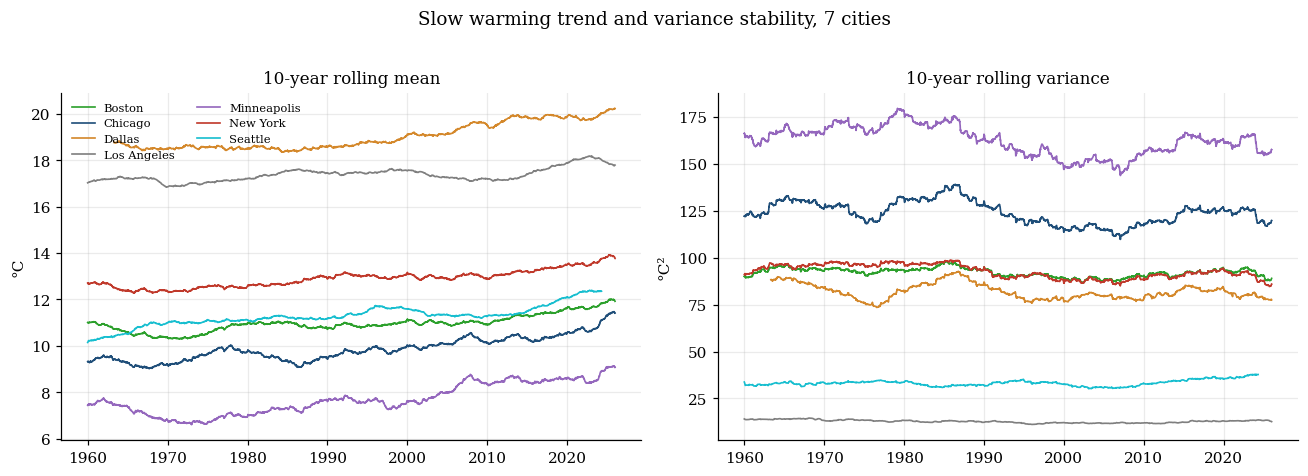

In [9]:
# 10-year rolling mean on ONE axis to compare TRENDS across cities
# (the cross-city comparison is the structural point, not each curve in isolation)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
w = 365 * 10
for city, d in df_cities.items():
    axes[0].plot(d.index, d["T"].rolling(w).mean(),
                 lw=1.1, color=CITY_COLORS[city], label=city.replace("_", " "))
    axes[1].plot(d.index, d["T"].rolling(w).var(),
                 lw=1.1, color=CITY_COLORS[city])
axes[0].set_title("10-year rolling mean"); axes[0].set_ylabel("°C")
axes[1].set_title("10-year rolling variance"); axes[1].set_ylabel("°C²")
axes[0].legend(frameon=False, fontsize=7.5, ncols=2)
fig.suptitle("Slow warming trend and variance stability, 7 cities", y=1.02)
fig.tight_layout()

Note: a 10-year moving average (365×10) smooths out the seasonal variation of the
series and isolates its long-run trend.

## Heating Degree Days ($HDD$)

*Weather derivatives* are financial instruments (swaps, futures or options) whose
underlying is a temperature index rather than a classical financial asset. In energy markets,
the most widely used index is the *Heating Degree Day* (HDD).

Let $T_i$ be the daily average temperature on day $i$ and $T_{\text{ref}}$ the reference
temperature, set by convention at $18°C$ ($65°F$). We define:

$$HDD_i = \max(T_{\text{ref}} - T_i,\ 0)$$
$$CDD_i = \max(T_i - T_{\text{ref}},\ 0)$$

The HDD measures the cold excess relative to $T_{\text{ref}}$: it is positive when the
temperature falls below the reference threshold, zero otherwise. Symmetrically, the CDD
captures heat excess. Over a period $[t_1, t_2]$, the underlying of an HDD contract is the
cumulative sum:

$$HDD_{\text{cum}} = \sum_{i=t_1}^{t_2} HDD_i$$

It is this cumulative index, not the temperature itself, that determines the derivative's
payoff. The HDD season conventionally covers November to March, the CDD season May to
September. April and October are `shoulder months` where both indices are close to zero.

,mean winter HDD,inter-annual std
Boston,2392.0,173.0
Chicago,2796.0,256.0
Dallas,1103.0,288.0
Los_Angeles,534.0,109.0
Minneapolis,3414.0,308.0
New_York,2124.0,191.0
Seattle,1791.0,137.0


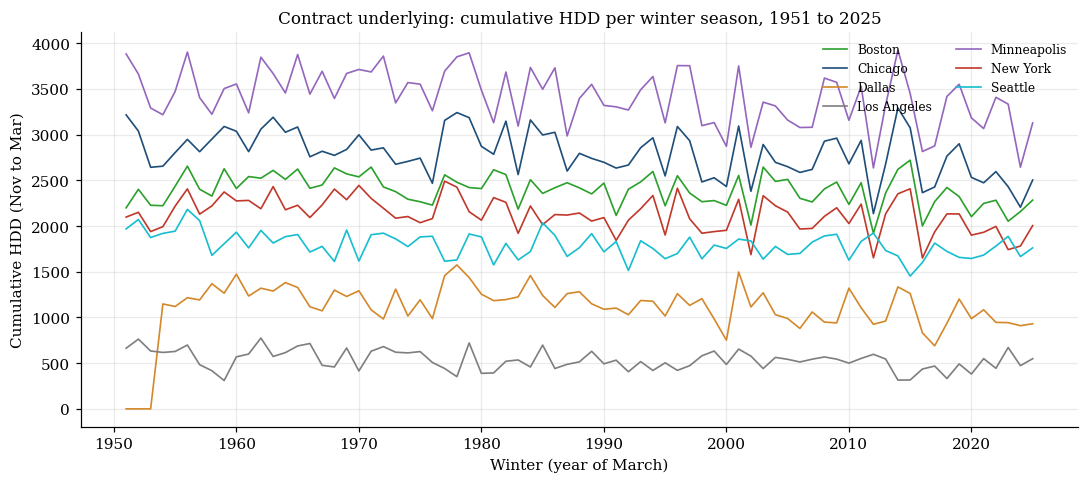

In [ ]:
def winter_cum_hdd(d):
    out = {}
    for y in range(d.index.year.min() + 1, d.index.year.max() + 1):
        w = d.loc[f"{y-1}-11-01":f"{y}-03-31", "HDD"]
        if len(w) >= 120:
            out[y] = w.sum()
    return pd.Series(out)

fig, ax = plt.subplots(figsize=(10, 4.5))
for city, d in df_cities.items():
    s = winter_cum_hdd(d)
    ax.plot(s.index, s.values, lw=1.1, color=CITY_COLORS[city],
            label=city.replace("_", " "))
ax.set_xlabel("Winter (year of March)"); ax.set_ylabel("Cumulative HDD (Nov to Mar)")
ax.set_title("Contract underlying: cumulative HDD per winter season, 1951 to 2025")
ax.legend(frameon=False, fontsize=8, ncols=2)
fig.tight_layout()

# Summary: level and inter-annual variability (= the risk being priced)
pd.DataFrame({c: {"mean winter HDD": winter_cum_hdd(d).mean(),
                  "inter-annual std": winter_cum_hdd(d).std()}
              for c, d in df_cities.items()}).T.round(0)

---
**Next step.** This raw data feeds `src/ou_pipeline.py`, which estimates the deterministic
component $\theta(t)$ (trend + Fourier), the mean-reversion speed $\kappa$ and the seasonal
volatility $\sigma_X(\text{doy})$. See `1_Temperature/1_OU/1_Temperature_Dynamics.ipynb`.